# Day 43 — Anomaly Detection, Bayesian GMMs

- Understand anomaly detection vs. novelty detection.
- Use Gaussian Mixture Models (GMMs) for anomaly detection.
- Use log probability density as an unusualness score.
- Understand threshold selection and the effect of the number of components.
- Use AIC and BIC for model selection.
- Understand Bayesian Gaussian Mixture Models.
- Compare GMMs with Isolation Forest, LOF, and One-Class SVM.

In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_blobs
from sklearn.mixture import GaussianMixture, BayesianGaussianMixture
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm import OneClassSVM
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print('Setup complete')

Setup complete


## 1. Anomaly Detection vs. Novelty Detection

**Anomaly detection:** the training data may contain abnormal observations, and the goal is to identify unusual observations.

**Novelty detection:** the training set is assumed to contain only normal observations; the model is then used to detect novel observations.

Mental model:

`Normal data → learn distribution → score observations → flag unusually unlikely points`

## 2. Create a Dataset with Normal Observations and Anomalies

We create two dense Gaussian-shaped groups and add a few distant observations as artificial anomalies.

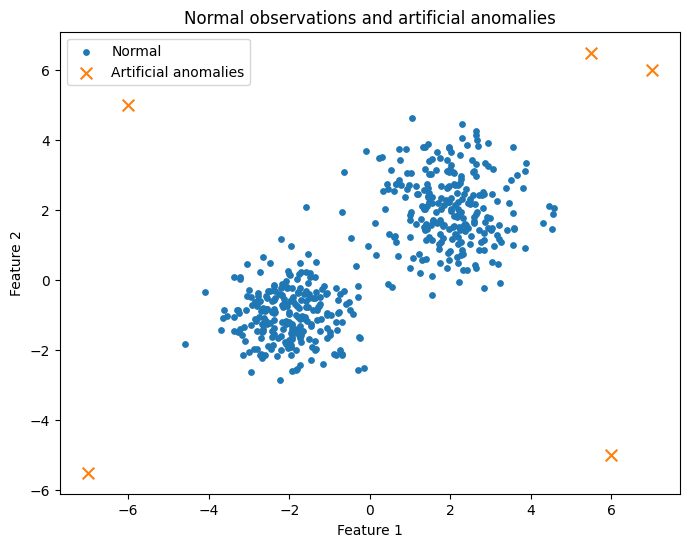

In [38]:
X_normal, _ = make_blobs(
    n_samples=500,
    centers=[(-2, -1), (2, 2)],
    cluster_std=[0.8, 1.0],
    random_state=RANDOM_STATE
)

X_anomalies = np.array([
    [6.0, -5.0],
    [-6.0, 5.0],
    [7.0, 6.0],
    [-7.0, -5.5],
    [5.5, 6.5]
])

X = np.vstack([X_normal, X_anomalies])
y_true = np.r_[np.zeros(len(X_normal), dtype=int), np.ones(len(X_anomalies), dtype=int)]

plt.figure(figsize=(8, 6))
plt.scatter(X_normal[:, 0], X_normal[:, 1], s=15, label='Normal')
plt.scatter(X_anomalies[:, 0], X_anomalies[:, 1], s=70, marker='x', label='Artificial anomalies')
plt.title('Normal observations and artificial anomalies')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.show()

## 3. Fit a Gaussian Mixture Model

A GMM represents the data distribution as a weighted combination of Gaussian components. Unlike K-Means, GMM provides a probabilistic description and supports **soft clustering**.

In [39]:
gmm = GaussianMixture(
    n_components=2,
    covariance_type='full',
    random_state=RANDOM_STATE
)
gmm.fit(X_normal)

print('Weights:', gmm.weights_)
print('Means:\n', gmm.means_)
print('Covariances:\n', gmm.covariances_)

Weights: [0.50283947 0.49716053]
Means:
 [[ 1.98959919  2.05230284]
 [-2.00560477 -1.00173653]]
Covariances:
 [[[ 0.9149601  -0.04930341]
  [-0.04930341  1.04179464]]

 [[ 0.62251689 -0.00124595]
  [-0.00124595  0.57194934]]]


## 4. GMM Density as an Anomaly Score

`score_samples()` returns the **log probability density** for each observation.

Higher log-density → more consistent with the learned distribution.  
Lower log-density → more unusual and potentially anomalous.

The score is not a probability between 0 and 1; it is a log-density value.

In [40]:
log_density = gmm.score_samples(X)

results = pd.DataFrame({
    'feature_1': X[:, 0],
    'feature_2': X[:, 1],
    'log_density': log_density,
    'true_anomaly': y_true
})

results.sort_values('log_density').head(10)

,feature_1,feature_2,log_density,true_anomaly
501,-6.000000,5.000000,-40.429198,1
503,-7.000000,-5.500000,-39.822897,1
500,6.000000,-5.000000,-33.775925,1
502,7.000000,6.000000,-24.778257,1
504,5.500000,6.500000,-19.579578,1
399,-1.587962,2.082185,-9.186291,0
242,-4.593014,-1.819510,-7.989541,0
474,-0.148273,-2.493812,-6.727515,0
393,-0.650970,3.091507,-6.697520,0
224,-0.293573,-2.561670,-6.492457,0


## 5. Choose an Anomaly Threshold

There is no universal threshold. It should reflect the application and acceptable false-positive/false-negative trade-off.

Here we use a simple percentile threshold as a demonstration.

In [41]:
threshold = np.percentile(log_density, 2)
gmm_pred = (log_density < threshold).astype(int)

print('Threshold:', threshold)
print('Detected anomalies:', gmm_pred.sum())
print('Actual artificial anomalies:', y_true.sum())

Threshold: -6.442526438975217
Detected anomalies: 11
Actual artificial anomalies: 5


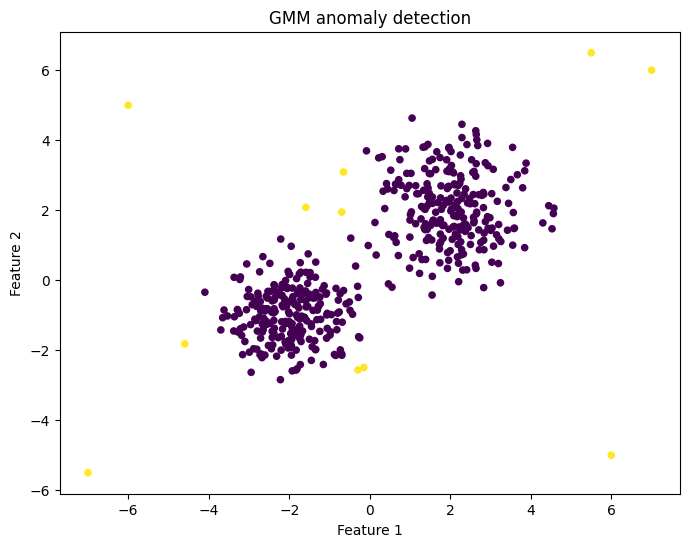

In [42]:
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=gmm_pred, s=20)
plt.title('GMM anomaly detection')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

## 6. Selecting the Number of GMM Components

Try several values of `n_components`. AIC and BIC provide model-selection criteria that balance goodness of fit with model complexity.

**Rule of thumb:** lower AIC/BIC is preferred when comparing models fitted to the same dataset.

In [43]:
component_range = range(1, 8)
models = []
aic_scores = []
bic_scores = []

for k in component_range:
    model = GaussianMixture(
        n_components=k,
        covariance_type='full',
        random_state=RANDOM_STATE
    )
    model.fit(X_normal)
    models.append(model)
    aic_scores.append(model.aic(X_normal))
    bic_scores.append(model.bic(X_normal))

selection = pd.DataFrame({
    'components': list(component_range),
    'AIC': aic_scores,
    'BIC': bic_scores
})
selection

,components,AIC,BIC
0,1,3726.437433,3747.510474
1,2,3276.489611,3322.850300
2,3,3281.296859,3352.945197
3,4,3293.165596,3390.101582
4,5,3304.079688,3426.303323
5,6,3315.347288,3462.858571
6,7,3323.102757,3495.901689


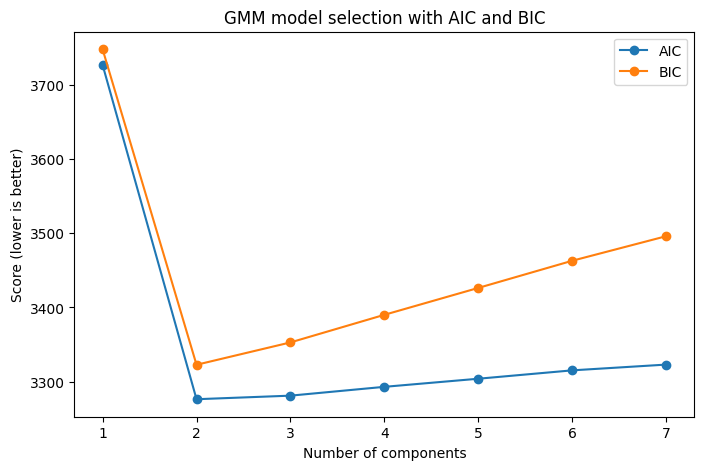

In [44]:
plt.figure(figsize=(8, 5))
plt.plot(list(component_range), aic_scores, marker='o', label='AIC')
plt.plot(list(component_range), bic_scores, marker='o', label='BIC')
plt.xlabel('Number of components')
plt.ylabel('Score (lower is better)')
plt.title('GMM model selection with AIC and BIC')
plt.xticks(list(component_range))
plt.legend()
plt.show()

## 7. Bayesian Gaussian Mixture Model

A Bayesian GMM can be given a maximum number of components while allowing the model to assign very small weights to components that are not needed.

This is useful when the true number of mixture components is uncertain.

In [45]:
bgmm = BayesianGaussianMixture(
    n_components=8,
    covariance_type='full',
    weight_concentration_prior_type='dirichlet_process',
    random_state=RANDOM_STATE
)
bgmm.fit(X_normal)

bgmm_weights = pd.DataFrame({
    'component': np.arange(1, len(bgmm.weights_) + 1),
    'weight': bgmm.weights_
})
bgmm_weights

c:\Users\Puneeth\anaconda3\envs\ml_env\Lib\site-packages\sklearn\mixture\_base.py:293: ConvergenceWarning: Best performing initialization did not converge. Try different init parameters, or increase max_iter, tol, or check for degenerate data.
  warnings.warn(


,component,weight
0,1,0.002137
1,2,0.002133
2,3,0.282699
3,4,0.220572
4,5,0.002112
5,6,0.002103
6,7,0.488025
7,8,0.000218


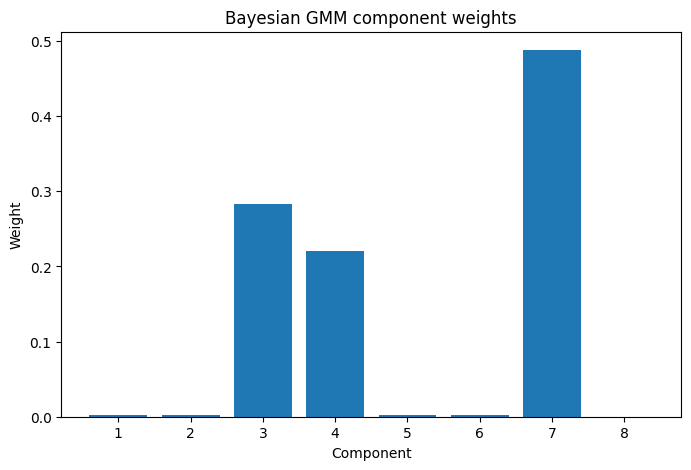

Effective components with weight > 0.01: 3


In [46]:
plt.figure(figsize=(8, 5))
plt.bar(bgmm_weights['component'], bgmm_weights['weight'])
plt.xlabel('Component')
plt.ylabel('Weight')
plt.title('Bayesian GMM component weights')
plt.show()

print('Effective components with weight > 0.01:', (bgmm.weights_ > 0.01).sum())

## 8. Compare Several Anomaly Detection Algorithms

### Isolation Forest
Anomalies tend to be isolated in fewer random partitioning steps. Use Isolation Forest for large/high-dimensional data as a strong baseline.

### Local Outlier Factor (LOF)
Compares the local density of an observation with the density around its neighbors. Use LOF when anomalies are defined relative to local neighborhood densities.

### One-Class SVM
Learns a boundary around the normal observations and identifies points outside that boundary. Use One-Class SVM when you expect a complex but learnable boundary and have resources to tune.

In [47]:
# Isolation Forest
iso = IsolationForest(contamination=0.02, random_state=RANDOM_STATE)
iso_pred = (iso.fit_predict(X_normal) == -1).astype(int)

# One-Class SVM for novelty detection: train only on normal observations
scaler = StandardScaler()
X_normal_scaled = scaler.fit_transform(X_normal)
X_scaled = scaler.transform(X)

ocsvm = OneClassSVM(nu=0.02, kernel='rbf', gamma='scale')
ocsvm.fit(X_normal_scaled)
ocsvm_pred = (ocsvm.predict(X_scaled) == -1).astype(int)

# LOF can be used directly for outlier detection on a dataset
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.02)
lof_pred = (lof.fit_predict(X) == -1).astype(int)

comparison = pd.DataFrame({
    'method': ['GMM', 'Isolation Forest', 'LOF', 'One-Class SVM'],
    'detected_anomalies': [gmm_pred.sum(), lof_pred.sum(), lof_pred.sum(), ocsvm_pred.sum()]
})
comparison

,method,detected_anomalies
0,GMM,11
1,Isolation Forest,11
2,LOF,11
3,One-Class SVM,16


Counts (GMM, IsolationForest, LOF, One-Class SVM): 11 11 11 11


C:\Users\Puneeth\AppData\Local\Temp\ipykernel_23260\3241146881.py:51: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.set_xlabel('Feature 1'); ax.set_ylabel('Feature 2'); ax.legend(loc='upper right')


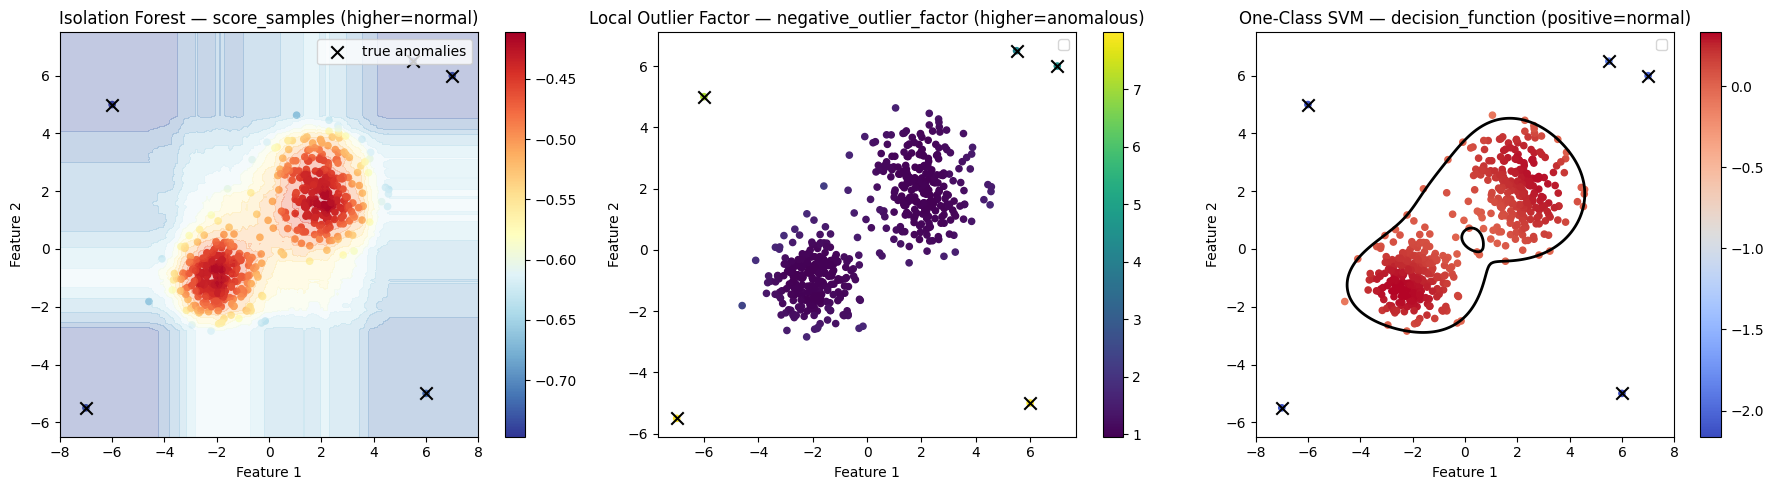

In [48]:
# ...existing code...
# Visualization: Isolation Forest, LOF, One-Class SVM
import numpy as np
import matplotlib.pyplot as plt

# Scores (higher -> more normal for iso, higher -> more anomalous for lof, positive -> normal for ocsvm)
iso_scores = iso.score_samples(X)
lof_scores = -lof.negative_outlier_factor_
ocsvm_scores = ocsvm.decision_function(X_scaled)

print("Counts (GMM, IsolationForest, LOF, One-Class SVM):",
      gmm_pred.sum(),
      (iso_scores < np.percentile(iso_scores, 2)).sum(),
      (lof_scores > np.percentile(lof_scores, 98)).sum(),
      (ocsvm_scores < np.percentile(ocsvm_scores, 2)).sum())

# grid for contours / decision boundary
xx, yy = np.meshgrid(
    np.linspace(X[:,0].min()-1, X[:,0].max()+1, 200),
    np.linspace(X[:,1].min()-1, X[:,1].max()+1, 200)
)
grid = np.c_[xx.ravel(), yy.ravel()]

iso_grid = iso.score_samples(grid).reshape(xx.shape)
grid_scaled = scaler.transform(grid)
ocsvm_grid = ocsvm.decision_function(grid_scaled).reshape(xx.shape)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Isolation Forest
im0 = axes[0].scatter(X[:,0], X[:,1], c=iso_scores, cmap='RdYlBu_r', s=20)
axes[0].contourf(xx, yy, iso_grid, levels=14, alpha=0.3, cmap='RdYlBu_r')
axes[0].scatter(X_anomalies[:,0], X_anomalies[:,1], c='k', marker='x', s=80, label='true anomalies')
axes[0].set_title('Isolation Forest — score_samples (higher=normal)')
fig.colorbar(im0, ax=axes[0])

# LOF (training points only)
im1 = axes[1].scatter(X[:,0], X[:,1], c=lof_scores, cmap='viridis', s=20)
axes[1].scatter(X_anomalies[:,0], X_anomalies[:,1], c='k', marker='x', s=80)
axes[1].set_title('Local Outlier Factor — negative_outlier_factor (higher=anomalous)')
fig.colorbar(im1, ax=axes[1])

# One-Class SVM
im2 = axes[2].scatter(X[:,0], X[:,1], c=ocsvm_scores, cmap='coolwarm', s=20)
axes[2].contour(xx, yy, ocsvm_grid, levels=[0], colors='k', linewidths=2)
axes[2].scatter(X_anomalies[:,0], X_anomalies[:,1], c='k', marker='x', s=80)
axes[2].set_title('One-Class SVM — decision_function (positive=normal)')
fig.colorbar(im2, ax=axes[2])

for ax in axes:
    ax.set_xlabel('Feature 1'); ax.set_ylabel('Feature 2'); ax.legend(loc='upper right')

plt.tight_layout()
plt.show()
# ...existing code...

## 9. Important Caveat About the Comparison

Different anomaly algorithms make different assumptions and use different score/threshold mechanisms. Therefore, raw counts of detected anomalies are **not** enough to decide which model is best.

In a real project, use labeled validation data when available and evaluate metrics such as precision, recall, PR-AUC, false-positive rate, and detection cost.

# Selection of Clustering Algorithm Cheat Sheet

| Method | Core idea | Strength | Limitation |
|---|---|---|---|
| K-Means | Nearest centroid | Simple and fast | Prefers roughly spherical clusters |
| DBSCAN | Density connectivity | Finds irregular clusters + noise | Sensitive to density/parameter choice |
| Agglomerative | Bottom-up hierarchy | Hierarchical structure | Can be computationally expensive |
| BIRCH | Incremental clustering tree | Large datasets | Less flexible than some alternatives |
| Mean-Shift | Move toward density modes | No fixed cluster count | Can be expensive |
| Spectral | Graph/eigenvector structure | Non-convex clusters | Scaling can be difficult |
| GMM | Gaussian mixture density | Soft/probabilistic clustering | Gaussian assumption |
| Bayesian GMM | Bayesian mixture | Flexible effective component count | More complex |
| Isolation Forest | Random isolation | Strong general-purpose baseline | Less interpretable density model |
| LOF | Local density | Local outliers | Sensitive to neighborhood settings |
| One-Class SVM | Normal-data boundary | Powerful nonlinear boundary | Parameter-sensitive |
